# Module 5 Lab 3: Textbook Problem 5.5

**CS 82A - Introduction to Data Science**

**Ramisha Tasfia**

**GitHub:** [https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/lab3/module5_lab3.ipynb](https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/lab3/module5_lab3.ipynb)

## Load the Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

cust = pd.read_csv("custdata.tsv", sep="\t")
cols = ["age", "income", "num.vehicles"]
print("Shape as loaded:", cust.shape)
print()
print(cust[cols].describe().round(1))

Shape as loaded: (1000, 11)

          age    income  num.vehicles
count  1000.0    1000.0         944.0
mean     51.7   53504.8           1.9
std      18.9   65478.1           1.1
min       0.0   -8700.0           0.0
25%      38.0   14600.0           1.0
50%      50.0   35000.0           2.0
75%      64.0   67000.0           2.0
max     146.7  615000.0           6.0


## BEFORE Cleaning: Correlation Matrix (Wrong on Purpose)

In [2]:
# pandas silently skips the 56 missing vehicle counts pair by pair,
# but the impossible ages and negative income are all still included
corr_before = cust[cols].corr()
print("BEFORE cleaning (invalid values included):")
print(corr_before.round(3))

BEFORE cleaning (invalid values included):
                age  income  num.vehicles
age           1.000   0.027        -0.064
income        0.027   1.000         0.139
num.vehicles -0.064   0.139         1.000


## Find the Invalid Values

In [3]:
bad_age = (cust["age"] <= 0) | (cust["age"] > 110)   # impossible ages
bad_income = cust["income"] < 0                       # negative income
missing_vehicles = cust["num.vehicles"].isna()        # no vehicle count

print("Age = 0:", (cust["age"] == 0).sum())
print("Age > 110:", (cust["age"] > 110).sum())
print(sorted(cust.loc[cust["age"] > 110, "age"].round(1)))
print("Income < 0:", bad_income.sum(),
      list(cust.loc[bad_income, "income"]))
print("Missing num.vehicles:", missing_vehicles.sum())

invalid = bad_age | bad_income | missing_vehicles
print()
print("Total rows removed:", invalid.sum())

Age = 0: 3
Age > 110: 8
[113.3, 123.1, 124.8, 126.7, 130.4, 136.1, 137.7, 146.7]
Income < 0: 1 [-8700]
Missing num.vehicles: 56

Total rows removed: 68


In [4]:
clean = cust[~invalid]
print("Rows before:", len(cust))
print("Rows after:", len(clean))
print("Removed:", len(cust) - len(clean))
print()
print(clean[cols].describe().round(1))

Rows before: 1000
Rows after: 932
Removed: 68

         age    income  num.vehicles
count  932.0     932.0         932.0
mean    51.4   55949.3           1.9
std     16.8   66040.1           1.1
min     19.0       0.0           0.0
25%     39.0   17000.0           1.0
50%     50.0   37000.0           2.0
75%     63.0   70000.0           2.0
max     93.0  615000.0           6.0


## What I Removed and Why
I eliminated 68 cases prior to determining the clean correlation coefficients due to one of two factors: either there was likely an error in the data entry/management process; or the value(s) were blank. There were three customers who listed their ages as zero and 8 others whose ages ranged from 113 through 147 (including the decimals). Zero and ages above 110 are each impossible ages for actual customers. Only one customer had an income less than zero (-$8,700) which is also not a valid income. The remaining 56 customers did not have a vehicle count recorded and therefore were unable to participate in a vehicle correlation. No cases were deleted twice by this process leaving me with the 932 case records of the original 1000.

## AFTER Cleaning: Correlation Matrix

In [5]:
corr_after = clean[cols].corr()
print("AFTER cleaning (932 valid rows):")
print(corr_after.round(3))

AFTER cleaning (932 valid rows):
                age  income  num.vehicles
age           1.000  -0.003        -0.066
income       -0.003   1.000         0.138
num.vehicles -0.066   0.138         1.000


## Before vs. After

In [6]:
pairs = [("age", "income"), ("age", "num.vehicles"),
         ("income", "num.vehicles")]
comparison = pd.DataFrame({
    "pair": [f"{a} vs {b}" for a, b in pairs],
    "r_before": [corr_before.loc[a, b] for a, b in pairs],
    "r_after": [corr_after.loc[a, b] for a, b in pairs],
}).round(3)
comparison

,pair,r_before,r_after
0,age vs income,0.027,-0.003
1,age vs num.vehicles,-0.064,-0.066
2,income vs num.vehicles,0.139,0.138


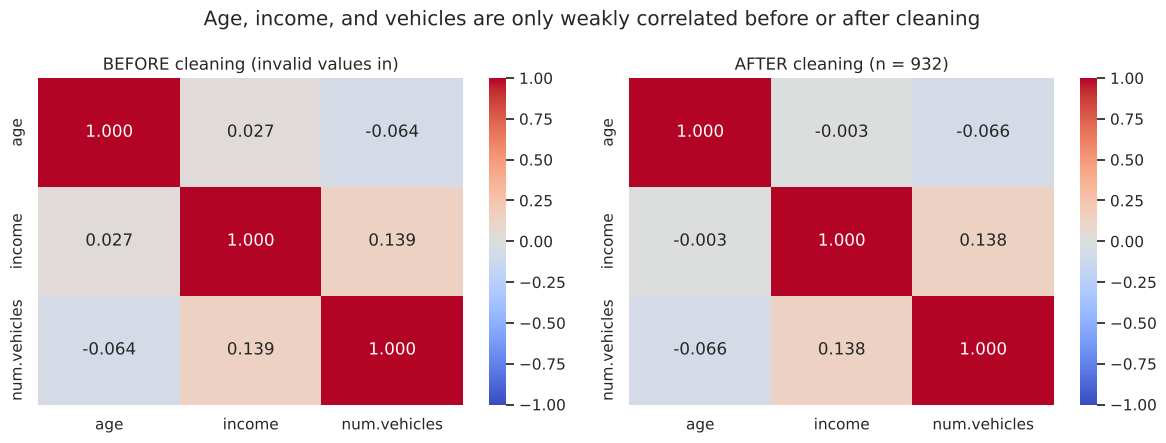

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, corr, title in [
        (axes[0], corr_before, "BEFORE cleaning (invalid values in)"),
        (axes[1], corr_after, "AFTER cleaning (n = 932)")]:
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)
fig.suptitle("Age, income, and vehicles are only weakly correlated "
             "before or after cleaning")
plt.tight_layout()
plt.show()

## Interpretation (Cleaned Data Only)
After being cleaned there is virtually no relationship among all three variables. The only variable pair that showed a slight relationship were the number of vehicles owned by a customer versus their income which was a positive, but weak relationship (r = .14) indicating that those who earned a higher income tended to own slightly more vehicles than other customers. A very weak negative relationship existed between the age of the customer and the number of vehicles they owned (r = -.07). An almost non-existent relationship existed between the age of the customer and their income (r =-.003).

## AI Disclosure
Claude (Anthropic) was used to help explain concepts and draft the code for this lab. All code was reviewed and understood by me, and I wrote the written responses in my own words. I can explain why ages of 0 or above 110 and negative incomes are invalid, why the rows with no vehicle count were removed, how the before and after correlation matrices differ, and why only the cleaned result should be interpreted.

Key prompt: "Help me with Module 5 Lab 3: Textbook Problem 5.5 using the attached data."